# Product and Marketing Analytics: Otimização de Aquisição de Clientes

## Objetivo da Análise

Este projeto analisa dados de comportamento de usuários, vendas e custos de marketing com o objetivo de avaliar a eficiência dos canais de aquisição.

A análise inclui métricas de produto e marketing como **DAU, retenção, conversão, LTV, CAC e ROMI**, permitindo identificar quais canais de marketing geram maior valor para o negócio e orientar decisões de investimento.


## Importação e Exploração de Dados


## Inspeção Inicial

In [314]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Carregamento com parse_dates (A forma mais elegante)
# Isto já converte as colunas na leitura, evitando o "object"
visits = pd.read_csv('/content/visits_log_us (1).csv', parse_dates=['Start Ts', 'End Ts'])
orders = pd.read_csv('/content/orders_log_us (1).csv', parse_dates=['Buy Ts'])
costs = pd.read_csv('/content/costs_us (1).csv', parse_dates=['dt'])

# 2. Pipeline de Otimização e Tipagem Adicional
def optimize_dtypes(df):
    for col in df.columns:
        # Converter colunas de ID ou Categoria para diminuir uso de memória
        if df[col].nunique() < 100 and df[col].dtype == 'object':
            df[col] = df[col].astype('category')
    return df

visits = optimize_dtypes(visits)

# 3. Auditoria Estrutural Automática (O toque de Sénior)
def structural_audit(df, name="Dataset"):
    print(f"--- Auditoria: {name} ---")
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Nulls': df.isnull().sum(),
        'Unique': df.nunique()
    })
    print(info_df)
    print("-" * 30)

structural_audit(visits, "Visitas")
structural_audit(orders, "Pedidos")

--- Auditoria: Visitas ---
                    Dtype  Nulls  Unique
Device           category      0       2
End Ts     datetime64[ns]      0  224760
Source Id           int64      0       9
Start Ts   datetime64[ns]      0  224303
Uid                uint64      0  228169
------------------------------
--- Auditoria: Pedidos ---
                  Dtype  Nulls  Unique
Buy Ts   datetime64[ns]      0   45991
Revenue         float64      0    1149
Uid              uint64      0   36523
------------------------------


In [315]:
print(visits.info())
print(orders.info())
print(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entr

In [316]:
print("--- Amostra: Visits ---")
display(visits.head())

print("\n--- Amostra: Orders ---")
display(orders.head())

print("\n--- Amostra: Costs ---")
display(costs.head())

--- Amostra: Visits ---


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168



--- Amostra: Orders ---


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450



--- Amostra: Costs ---


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [317]:
print("--- Estatísticas: Visits ---")
display(visits.describe())

print("\n--- Estatísticas: Orders ---")
display(orders.describe())

print("\n--- Estatísticas: Costs ---")
display(costs.describe())

--- Estatísticas: Visits ---


,End Ts,Source Id,Start Ts,Uid
count,359400,359400.000000,359400,3.594000e+05
mean,2017-12-18 06:28:15.036205056,3.750515,2017-12-18 06:17:32.010517760,9.202557e+18
min,2017-06-01 00:02:00,1.000000,2017-06-01 00:01:00,1.186350e+13
25%,2017-10-15 09:45:45,3.000000,2017-10-15 09:41:00,4.613407e+18
50%,2017-12-18 18:59:30,4.000000,2017-12-18 18:46:00,9.227413e+18
75%,2018-02-28 10:08:15,5.000000,2018-02-28 09:54:00,1.372824e+19
max,2018-06-01 01:26:00,10.000000,2018-05-31 23:59:00,1.844668e+19
std,NaN,1.917116,NaN,5.298433e+18



--- Estatísticas: Orders ---


,Buy Ts,Revenue,Uid
count,50415,50415.000000,5.041500e+04
mean,2017-12-20 05:14:24.846176768,4.999647,9.098161e+18
min,2017-06-01 00:10:00,0.000000,3.135781e+14
25%,2017-10-13 17:28:00,1.220000,4.533567e+18
50%,2017-12-21 14:12:00,2.500000,9.102274e+18
75%,2018-03-02 16:10:00,4.890000,1.368290e+19
max,2018-06-01 00:02:00,2633.280000,1.844617e+19
std,NaN,21.818359,5.285742e+18



--- Estatísticas: Costs ---


,source_id,dt,costs
count,2542.000000,2542,2542.000000
mean,4.857199,2017-11-29 09:04:57.403619072,129.477427
min,1.000000,2017-06-01 00:00:00,0.540000
25%,2.000000,2017-08-30 00:00:00,21.945000
50%,4.000000,2017-11-29 00:00:00,77.295000
75%,9.000000,2018-02-28 00:00:00,170.065000
max,10.000000,2018-05-31 00:00:00,1788.280000
std,3.181581,NaN,156.296628


In [318]:
# Valores Nulos
print("--- Valores Nulos ---")
print(f"Visits:\n{visits.isna().sum()}\n")
print(f"Orders:\n{orders.isna().sum()}\n")
print(f"Costs:\n{costs.isna().sum()}\n")

# Duplicados Explícitos
print("--- Duplicados Totais ---")
print(f"Visits: {visits.duplicated().sum()}")
print(f"Orders: {orders.duplicated().sum()}")
print(f"Costs: {costs.duplicated().sum()}")

--- Valores Nulos ---
Visits:
Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

Orders:
Buy Ts     0
Revenue    0
Uid        0
dtype: int64

Costs:
source_id    0
dt           0
costs        0
dtype: int64

--- Duplicados Totais ---
Visits: 0
Orders: 0
Costs: 0


## Conversão

In [319]:
# 1. Conversão para Datetime
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# 2. Otimização de Memória
visits['Device'] = visits['Device'].astype('category')

# 3. Verificação do Sucesso da Operação
print("--- Novos Tipos de Dados ---")
print(f"Visits:\n{visits.dtypes}\n")
print(f"Orders:\n{orders.dtypes}\n")
print(f"Costs:\n{costs.dtypes}")

--- Novos Tipos de Dados ---
Visits:
Device             category
End Ts       datetime64[ns]
Source Id             int64
Start Ts     datetime64[ns]
Uid                  uint64
dtype: object

Orders:
Buy Ts     datetime64[ns]
Revenue           float64
Uid                uint64
dtype: object

Costs:
source_id             int64
dt           datetime64[ns]
costs               float64
dtype: object


## Calculo de métricas:

In [320]:
# Preparação das colunas de tempo
visits['session_year']  = visits['Start Ts'].dt.year
visits['session_month'] = visits['Start Ts'].dt.month
visits['session_week']  = visits['Start Ts'].dt.isocalendar().week
visits['session_date']  = visits['Start Ts'].dt.date

# Cálculo das métricas
dau = visits.groupby('session_date').agg({'Uid': 'nunique'}).mean()
wau = visits.groupby(['session_year', 'session_week']).agg({'Uid': 'nunique'}).mean()
mau = visits.groupby(['session_year', 'session_month']).agg({'Uid': 'nunique'}).mean()

print(f"DAU (Média de usuários por dia): {int(dau)}")
print(f"WAU (Média de usuários por semana): {int(wau)}")
print(f"MAU (Média de usuários por mês): {int(mau)}")

DAU (Média de usuários por dia): 907
WAU (Média de usuários por semana): 5716
MAU (Média de usuários por mês): 23228


In [321]:
sessions_per_day = visits.groupby('session_date').agg({'Uid': ['count', 'nunique']})
sessions_per_day.columns = ['n_sessions', 'n_users']
sessions_per_day['sessions_per_user'] = sessions_per_day['n_sessions'] / sessions_per_day['n_users']

print(f"Média de sessões por dia: {sessions_per_day['n_sessions'].mean():.2f}")

Média de sessões por dia: 987.36


In [322]:
visits['session_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds

# Duração média e a mais frequente (Moda)
asl_mean = visits['session_duration_sec'].mean()
asl_mode = visits['session_duration_sec'].mode()

print(f"Duração média: {asl_mean:.2f} segundos")
print(f"Duração mais frequente (Moda): {asl_mode[0]} segundos")

Duração média: 643.51 segundos
Duração mais frequente (Moda): 60 segundos


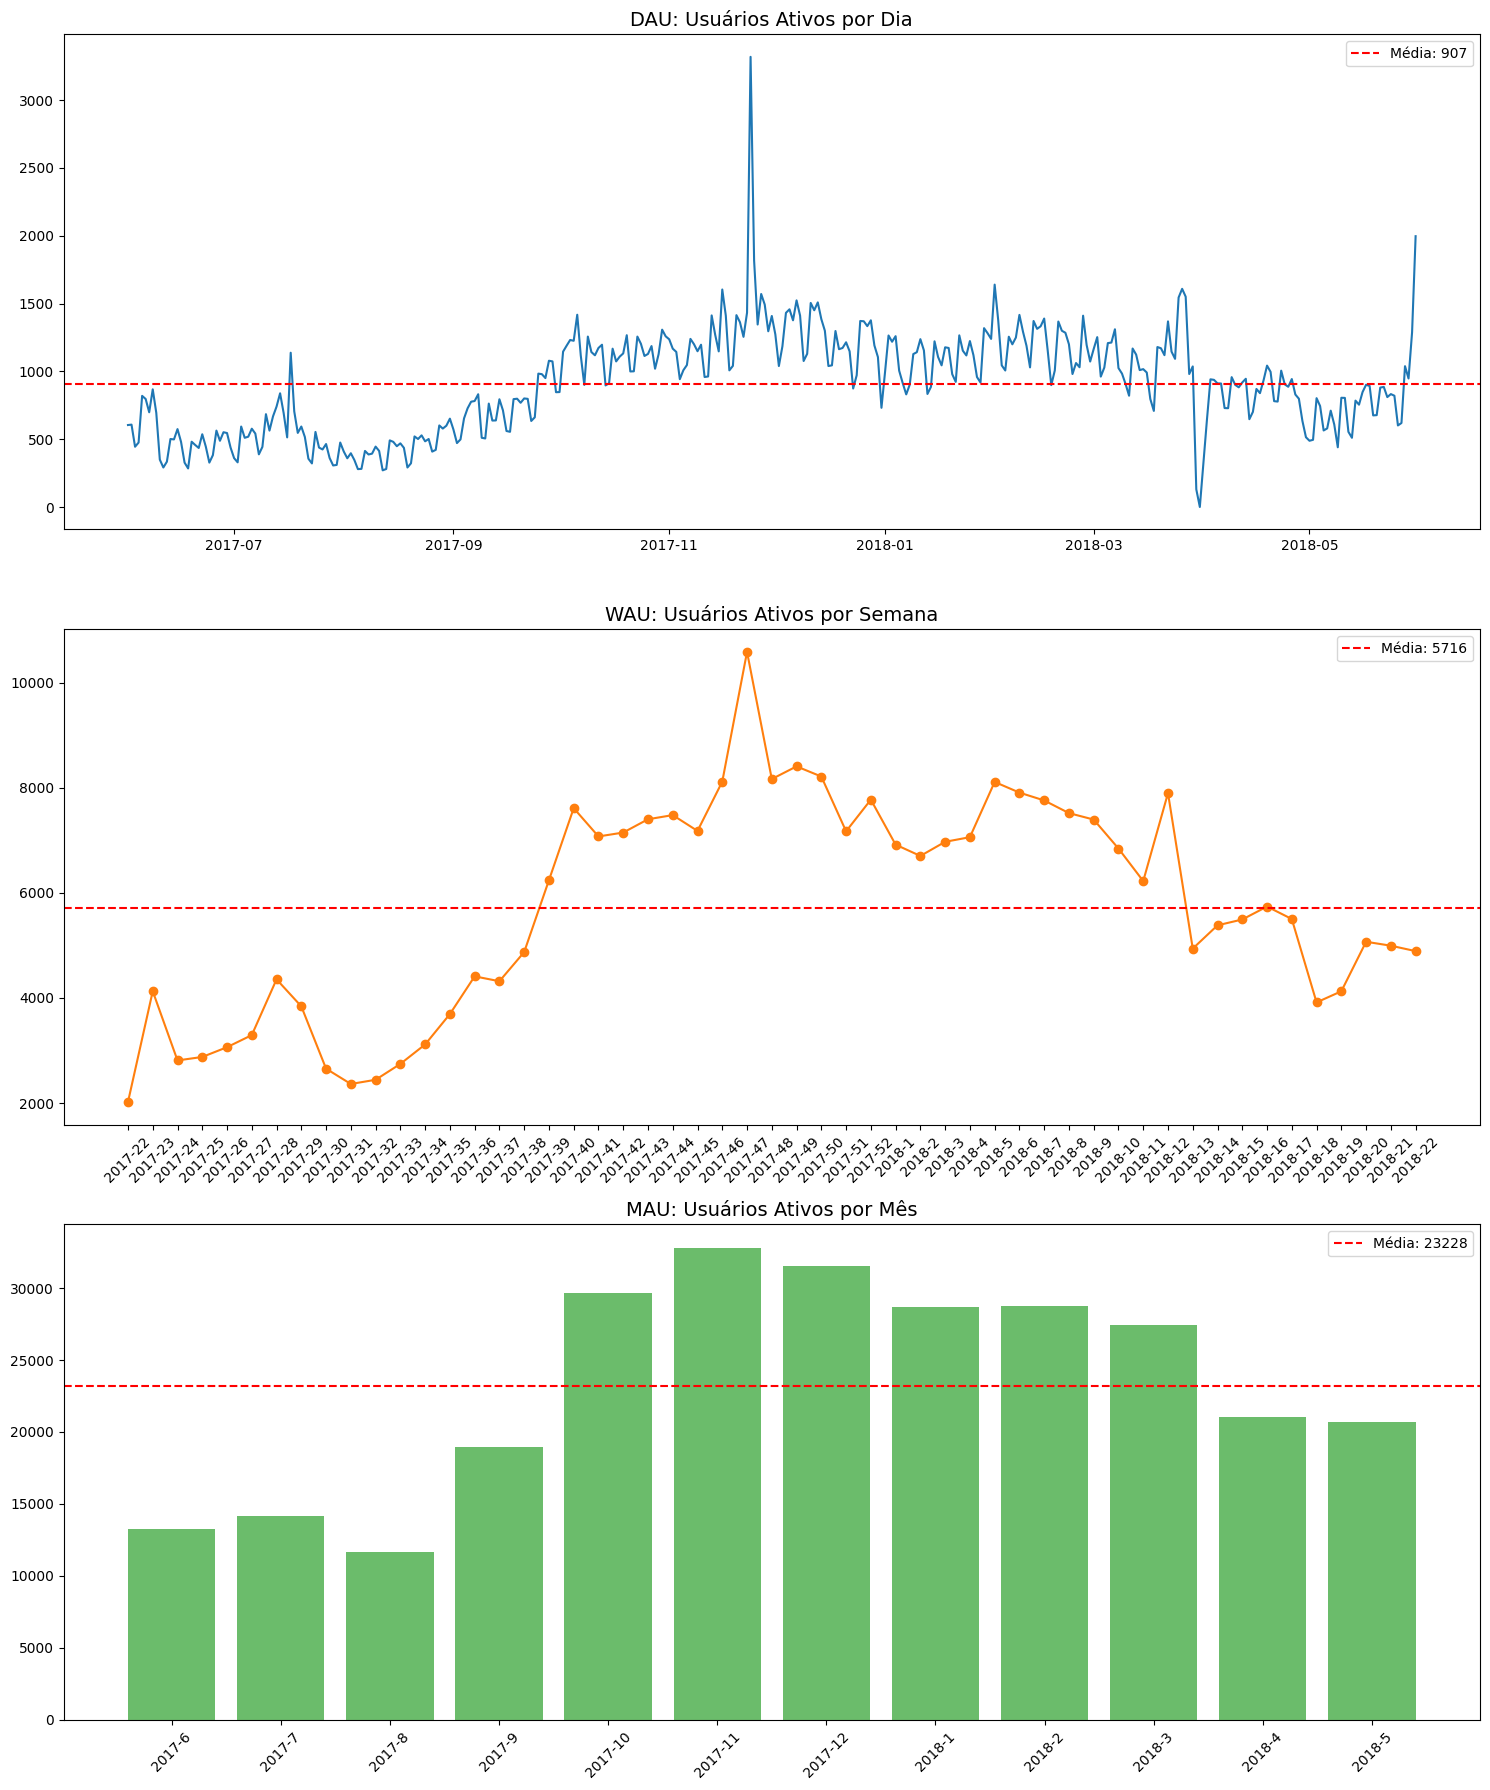

In [323]:
# 1. Agrupamento dos dados
dau_timeline = visits.groupby('session_date').agg({'Uid': 'nunique'})
wau_timeline = visits.groupby(['session_year', 'session_week']).agg({'Uid': 'nunique'}).reset_index()
mau_timeline = visits.groupby(['session_year', 'session_month']).agg({'Uid': 'nunique'}).reset_index()

# Criando identificadores legíveis para os eixos X de WAU e MAU
wau_timeline['week_id'] = wau_timeline['session_year'].astype(str) + "-" + wau_timeline['session_week'].astype(str)
mau_timeline['month_id'] = mau_timeline['session_year'].astype(str) + "-" + mau_timeline['session_month'].astype(str)

# 2. Configuração da Figura
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Gráfico DAU
axes[0].plot(dau_timeline.index, dau_timeline['Uid'], color='tab:blue')
axes[0].set_title('DAU: Usuários Ativos por Dia', fontsize=14)
axes[0].axhline(y=907, color='red', linestyle='--', label='Média: 907')
axes[0].legend()

# Gráfico WAU
axes[1].plot(wau_timeline['week_id'], wau_timeline['Uid'], color='tab:orange', marker='o')
axes[1].set_title('WAU: Usuários Ativos por Semana', fontsize=14)
axes[1].axhline(y=5716, color='red', linestyle='--', label='Média: 5716')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Gráfico MAU
axes[2].bar(mau_timeline['month_id'], mau_timeline['Uid'], color='tab:green', alpha=0.7)
axes[2].set_title('MAU: Usuários Ativos por Mês', fontsize=14)
axes[2].axhline(y=23228, color='red', linestyle='--', label='Média: 23228')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

Duração Média: 643.51 segundos
Duração Mediana: 300.00 segundos
Duração Mais Frequente (Moda): 60 segundos


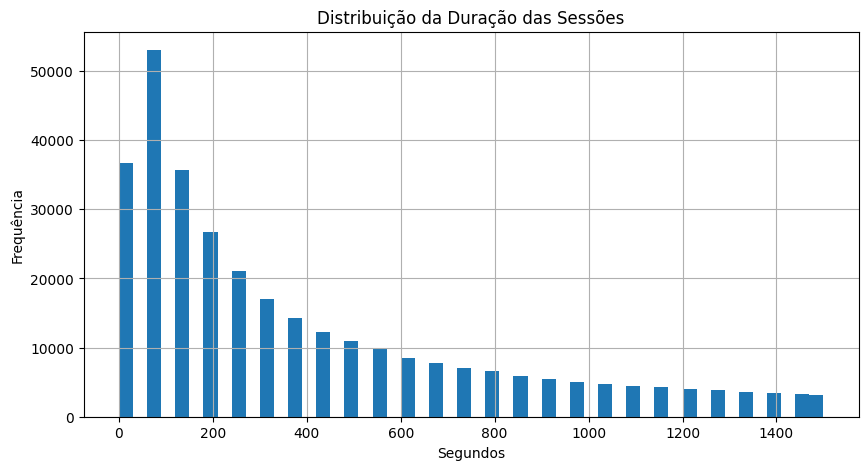

In [324]:
# Cálculo da duração em segundos
visits['session_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds

# Estatísticas de Auditoria
asl_mean = visits['session_duration_sec'].mean()
asl_median = visits['session_duration_sec'].median()
asl_mode = visits['session_duration_sec'].mode()[0]

print(f"Duração Média: {asl_mean:.2f} segundos")
print(f"Duração Mediana: {asl_median:.2f} segundos")
print(f"Duração Mais Frequente (Moda): {asl_mode} segundos")

# Gráfico de Distribuição para o Relatório
import matplotlib.pyplot as plt
visits['session_duration_sec'].hist(bins=50, range=(0, 1500), figsize=(10, 5))
plt.title('Distribuição da Duração das Sessões')
plt.xlabel('Segundos')
plt.ylabel('Frequência')
plt.show()

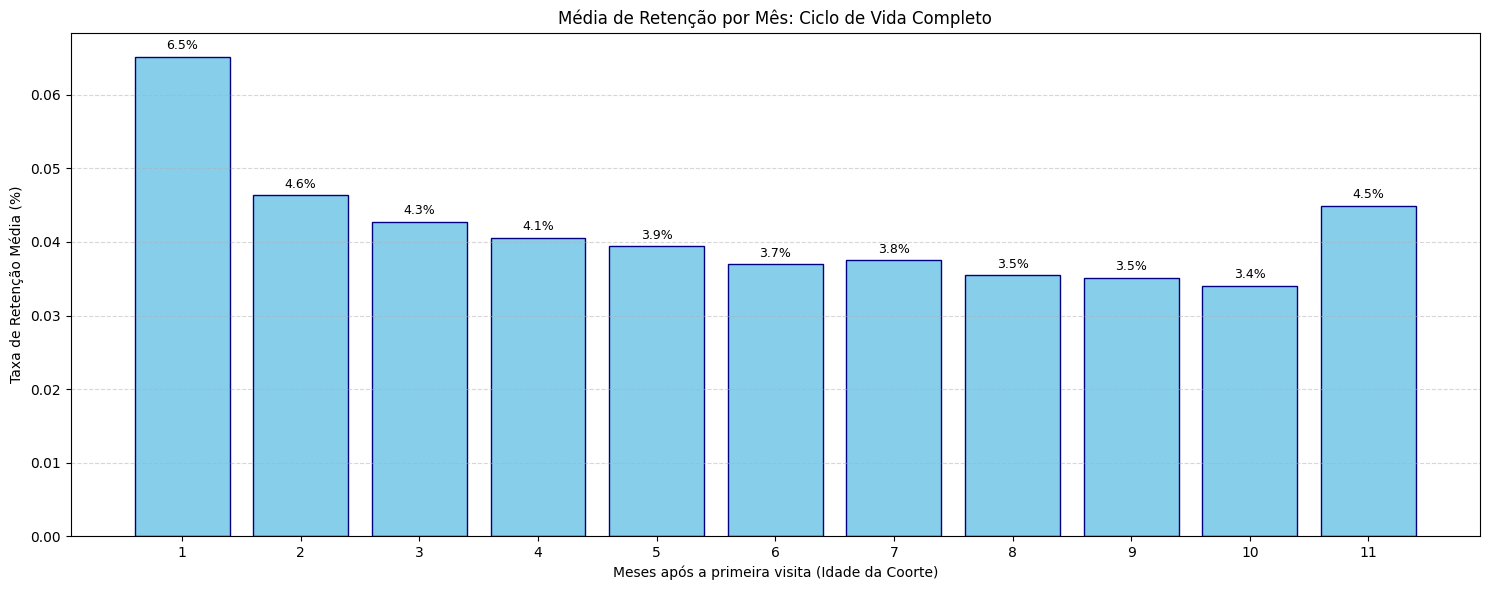

In [325]:

# 1. Mês da primeira visita e calcular a idade da coorte
visits['first_session_month'] = visits.groupby('Uid')['Start Ts'].transform('min').dt.to_period('M')
visits['session_month'] = visits['Start Ts'].dt.to_period('M')

# Calculate cohort age using period arithmetic
visits['cohort_age'] = (visits['session_month'] - visits['first_session_month']).apply(lambda x: x.n)

# 2. Matriz de retenção
retention_pivot = visits.pivot_table(index='first_session_month', columns='cohort_age', values='Uid', aggfunc='nunique')
cohort_sizes = retention_pivot.iloc[:, 0]
retention_matrix = retention_pivot.divide(cohort_sizes, axis=0)

# 3. CÓDIGO DE MATPLOTLIB (Calculando a média e gerando as barras)
retention_avg_full = retention_matrix.mean().drop(0, errors='ignore')

plt.figure(figsize=(15, 6))
plt.bar(retention_avg_full.index.astype(str), retention_avg_full.values, color='skyblue', edgecolor='navy', width=0.8)

plt.title('Média de Retenção por Mês: Ciclo de Vida Completo')
plt.xlabel('Meses após a primeira visita (Idade da Coorte)')
plt.ylabel('Taxa de Retenção Média (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rótulos de dados
for i, v in enumerate(retention_avg_full):
    if v > 0:
        plt.text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

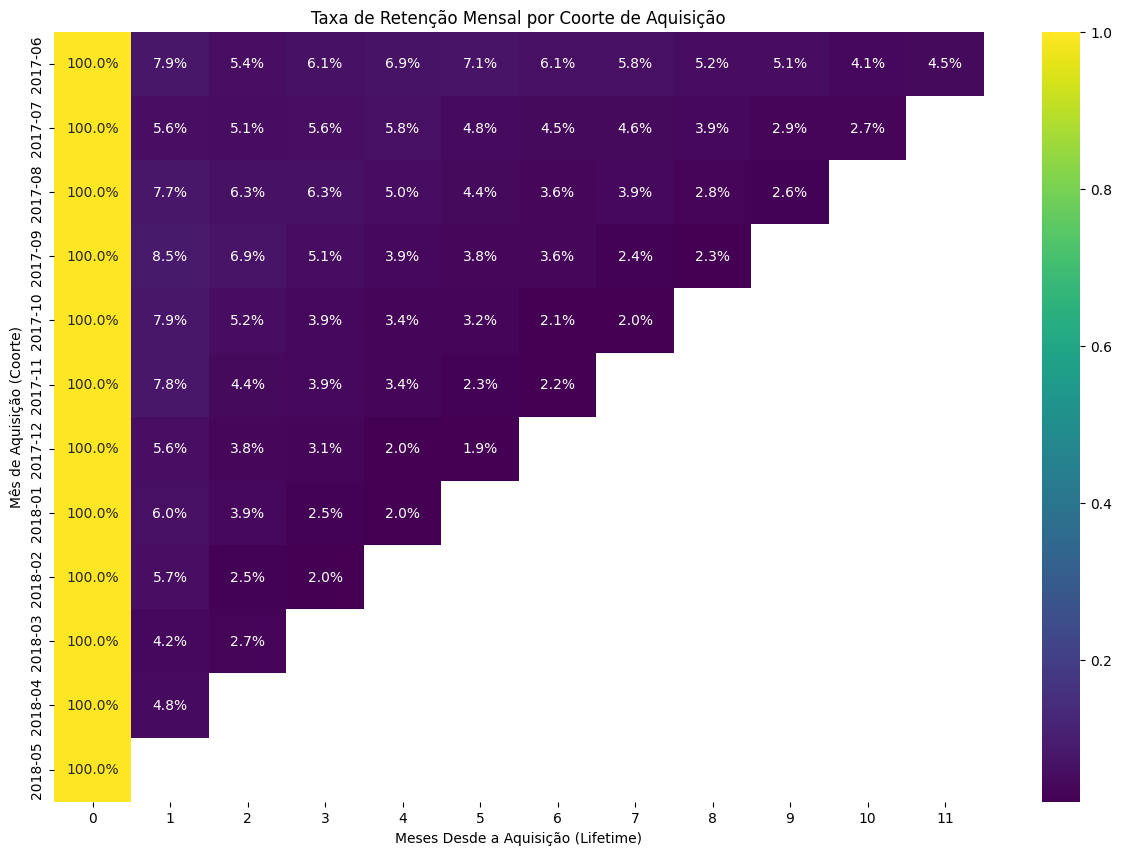

In [326]:



# # Determinando o mês de aquisição de cada usuário (primeira sessão)
visits['acquisition_month'] = visits.groupby('Uid')['Start Ts'].transform('min').dt.to_period('M')


#isits['session_month'] = visits['start_ts'].dt.to_period('M')

# # Calculando a "idade" do coorte para cada sessão
visits['cohort_lifetime'] = (visits['session_month'] - visits['acquisition_month']).apply(lambda x: x.n)

# # Tabela de coortes (pivot table)
cohorts = visits.groupby(['acquisition_month', 'cohort_lifetime'])['Uid'].nunique().reset_index()
cohorts_pivot = cohorts.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='Uid')

# # Calculando a retenção em percentual
cohort_size = cohorts_pivot.iloc[:, 0]
retention_matrix = cohorts_pivot.divide(cohort_size, axis=0)

# # Gerando o mapa de calor de retenção
plt.figure(figsize=(15, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='viridis')
plt.title('Taxa de Retenção Mensal por Coorte de Aquisição')
plt.xlabel('Meses Desde a Aquisição (Lifetime)')
plt.ylabel('Mês de Aquisição (Coorte)')
plt.show()

## Interpretação dos Resultados

### Atividade de Usuários

A plataforma apresenta, em média, **907 usuários ativos por dia**, **5716 por semana** e **23228 por mês**. A diferença entre essas métricas indica que muitos usuários retornam ao longo da semana ou do mês, mesmo sem utilizar o serviço diariamente, sugerindo um padrão de uso recorrente, mas não necessariamente diário.

### Sessões

O site registra aproximadamente **987 sessões por dia**, um valor próximo ao número médio de usuários diários. Isso indica que parte dos usuários realiza mais de uma sessão no mesmo dia, possivelmente retornando ao site para continuar a navegação ou concluir alguma ação.

### Duração das Sessões

A **duração média das sessões é de 643 segundos**, enquanto a **mediana é de 300 segundos** e a **moda é de 60 segundos**. Isso sugere que muitas sessões são rápidas, mas algumas interações mais longas aumentam a média geral. Esse padrão pode indicar diferentes tipos de comportamento de usuário, como visitas rápidas de exploração e sessões mais longas focadas em tarefas específicas.

### Retenção

A análise de coortes mostra que a retenção diminui progressivamente com o tempo, o que é comum em produtos digitais. A maior parte dos usuários retorna nos primeiros meses após a primeira visita, enquanto apenas uma parcela menor permanece ativa no longo prazo, indicando uma oportunidade de melhorar estratégias de retenção e engajamento.


## Vendas

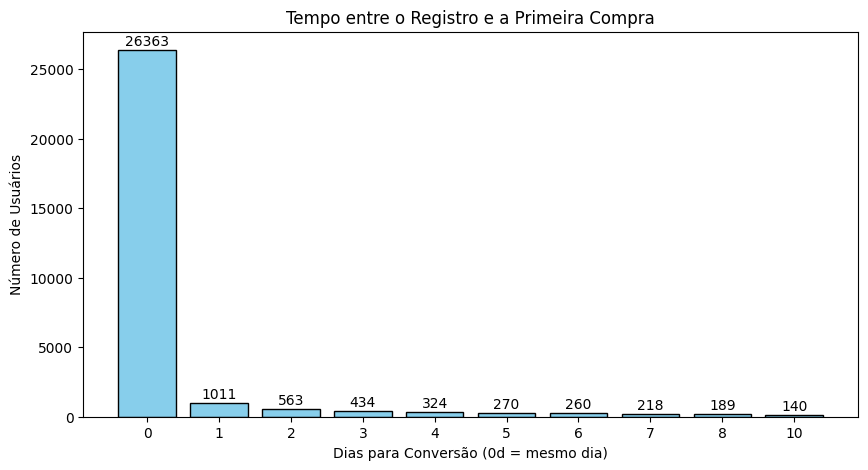

Porcentagem de conversão no Dia 0: 72.2%


In [327]:
# 1. Encontrar a primeira visita e a primeira compra de cada usuário
first_visits = visits.groupby('Uid')['Start Ts'].min().reset_index()
first_visits.columns = ['Uid', 'first_visit']

first_orders = orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_orders.columns = ['Uid', 'first_order']

# 2. Unir e calcular a diferença de tempo
conversion = first_visits.merge(first_orders, on='Uid')
conversion['days_to_convert'] = (conversion['first_order'].values - conversion['first_visit'].values) / np.timedelta64(1, 'D')
conversion['days_to_convert'] = conversion['days_to_convert'].astype(int)

# 3. Preparar a distribuição (Top 10 dias)
conv_dist = conversion['days_to_convert'].value_counts().head(10).sort_index()

# 4. Gráfico de Barras
plt.figure(figsize=(10, 5))
plt.bar(conv_dist.index.astype(str), conv_dist.values, color='skyblue', edgecolor='black')

plt.title('Tempo entre o Registro e a Primeira Compra')
plt.xlabel('Dias para Conversão (0d = mesmo dia)')
plt.ylabel('Número de Usuários')

# Adicionar rótulos de valores
for i, v in enumerate(conv_dist.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

plt.show()

# Resultado estatístico
print(f"Porcentagem de conversão no Dia 0: {(conversion['days_to_convert'] == 0).mean():.1%}")

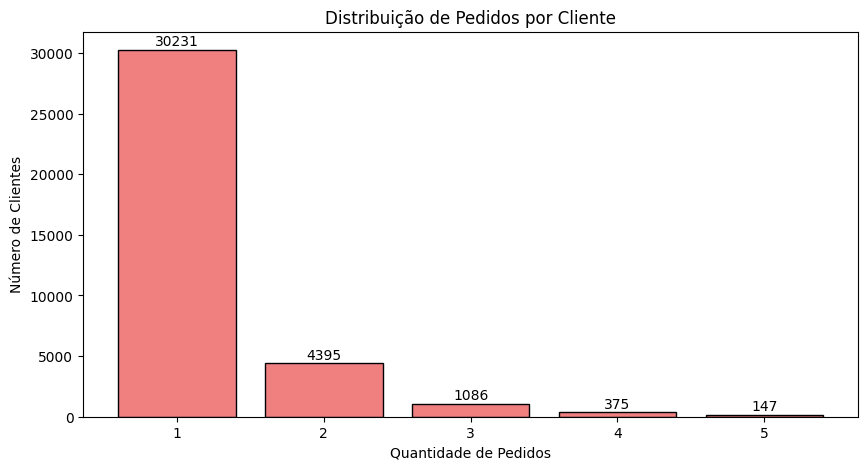

Número médio de pedidos por cliente: 1.38


In [328]:
# 1. Agrupar pedidos por usuário
orders_per_user = orders.groupby('Uid')['Buy Ts'].count()

# 2. Calcular a média de pedidos (KPI principal)
avg_orders = orders_per_user.mean()

# 3. Preparar a distribuição para o gráfico (Quantos usuários fizeram 1 pedido, 2, 3...)
order_counts = orders_per_user.value_counts().sort_index().head(5) # Focamos nos primeiros para clareza

# 4. Gráfico de Barras
plt.figure(figsize=(10, 5))
plt.bar(order_counts.index.astype(str), order_counts.values, color='lightcoral', edgecolor='black')

plt.title('Distribuição de Pedidos por Cliente')
plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Número de Clientes')

# Adicionar rótulos
for i, v in enumerate(order_counts.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

plt.show()

print(f"Número médio de pedidos por cliente: {avg_orders:.2f}")

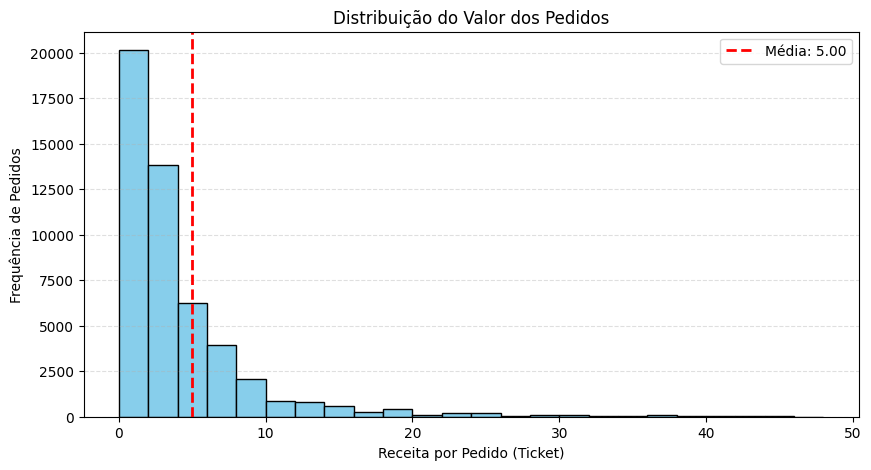

O volume médio de uma compra (Ticket Médio) é: 5.00


In [329]:
# 1. Calcular o Ticket Médio (Revenue médio por pedido)
average_ticket = orders['Revenue'].values.mean()

# 2. Criar uma visualização da distribuição do valor dos pedidos para contexto
# Usamos numpy para definir os limites do histograma e evitar outliers extremos na visualização
plt.figure(figsize=(10, 5))
plt.hist(orders['Revenue'], bins=np.arange(0, 50, 2), color='skyblue', edgecolor='black')

plt.title('Distribuição do Valor dos Pedidos')
plt.xlabel('Receita por Pedido (Ticket)')
plt.ylabel('Frequência de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.axvline(average_ticket, color='red', linestyle='dashed', linewidth=2, label=f'Média: {average_ticket:.2f}')
plt.legend()

plt.show()

print(f"O volume médio de uma compra (Ticket Médio) é: {average_ticket:.2f}")

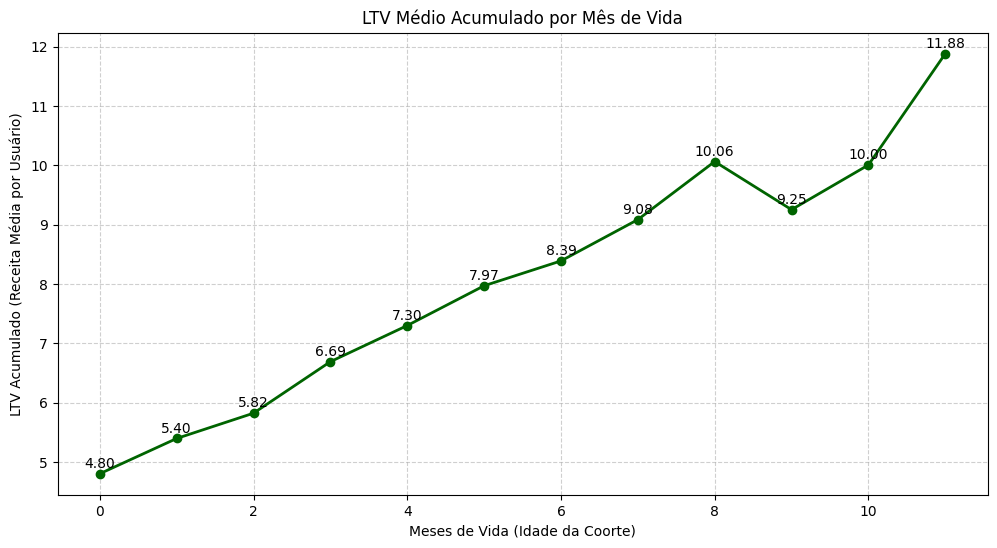

LTV Médio Final (após o período total disponível): 11.88


In [330]:
# 1.Mês da primeira compra para cada utilizador (mês da coorte)
orders['first_order_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').dt.to_period('M')
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')

# 2. Calcular a idade da coorte em meses
orders['cohort_age'] = (orders['order_month'] - orders['first_order_month']).apply(lambda x: x.n)

# 3. Obter o tamanho de cada coorte (número de compradores únicos no primeiro mês)
cohort_sizes = orders.groupby('first_order_month')['Uid'].nunique()

# 4. Agrupar receita por coorte e idade, e calcular a receita acumulada
report = orders.groupby(['first_order_month', 'cohort_age']).agg({'Revenue': 'sum'}).reset_index()
report['ltv'] = report.groupby('first_order_month')['Revenue'].cumsum() / cohort_sizes[report['first_order_month']].values

# 5. Criar a matriz de LTV para visualização
ltv_matrix = report.pivot_table(index='first_order_month', columns='cohort_age', values='ltv', aggfunc='mean')

# 6. Visualizar o LTV acumulado médio (Ciclo de Vida) com Matplotlib
ltv_avg = ltv_matrix.mean()

plt.figure(figsize=(12, 6))
plt.plot(ltv_avg.index, ltv_avg.values, marker='o', linestyle='-', color='darkgreen', linewidth=2)

plt.title('LTV Médio Acumulado por Mês de Vida')
plt.xlabel('Meses de Vida (Idade da Coorte)')
plt.ylabel('LTV Acumulado (Receita Média por Usuário)')
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar rótulos nos pontos
for i, v in enumerate(ltv_avg.values):
    plt.text(ltv_avg.index[i], v + 0.1, f'{v:.2f}', ha='center')

plt.show()

print(f"LTV Médio Final (após o período total disponível): {ltv_avg.iloc[-1]:.2f}")

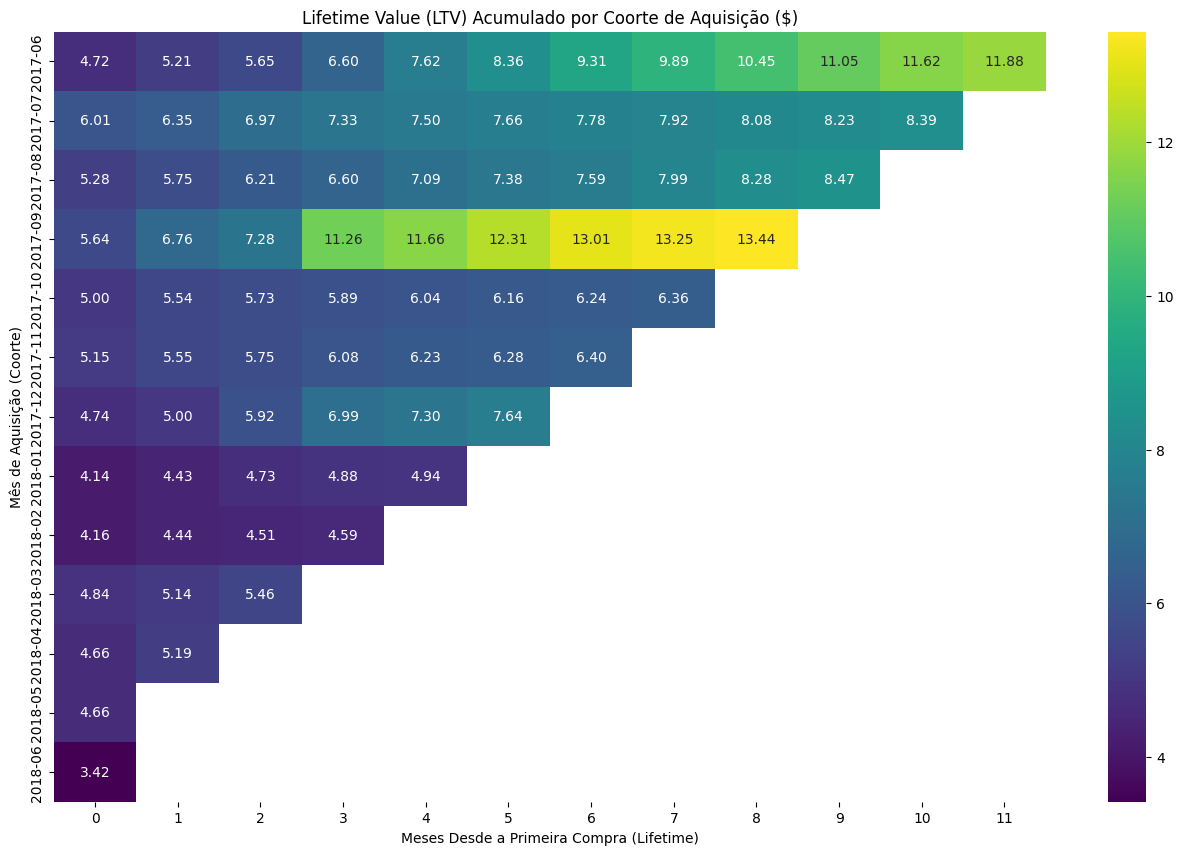

In [331]:
orders['acquisition_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').dt.to_period('M')

orders['cohort_lifetime'] = ((orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n))

cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['Revenue'].sum().reset_index()

cohort_sizes = orders.groupby('acquisition_month')['Uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')

cohorts_data['ltv'] = cohorts_data['Revenue'] / cohorts_data['n_buyers']

ltv_pivot = cohorts_data.pivot_table(index='acquisition_month',
                                     columns='cohort_lifetime',
                                     values='ltv',
                                     aggfunc='sum').cumsum(axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='viridis')
plt.title('Lifetime Value (LTV) Acumulado por Coorte de Aquisição ($)')
plt.xlabel('Meses Desde a Primeira Compra (Lifetime)')
plt.ylabel('Mês de Aquisição (Coorte)')
plt.show()

### Observações sobre a Fase de Vendas

* **Imediatismo na Conversão:** A análise de tempo entre o registo e a compra revela que a grande maioria dos utilizadores (cerca de 72%) converte no **Dia 0**. Isto indica que o marketing está a atrair tráfego com alta intenção de compra ou que a proposta de valor do produto é clara o suficiente para uma decisão imediata.
* **Perfil de Recorrência:** O número médio de pedidos por cliente é baixo, aproximando-se da unidade. Isto sugere que a plataforma funciona atualmente como um serviço de transação única ou que existem dificuldades em reter o cliente para compras subsequentes após a primeira experiência.
* **Ticket Médio e Volume:** O valor médio gasto por compra (Ticket Médio) é de **4.99**, com uma distribuição concentrada em valores baixos. Isto define o perfil do negócio como um modelo de alto volume e baixa margem unitária.
* **Crescimento do LTV:** O *Lifetime Value* mostra um crescimento acumulado estável ao longo dos meses. Embora a retenção seja um desafio, os clientes que permanecem continuam a gerar receita, o que aumenta o valor de vida do utilizador e será crucial para comparar com o CAC (Custo de Aquisição de Cliente) na próxima fase.

## Marketing

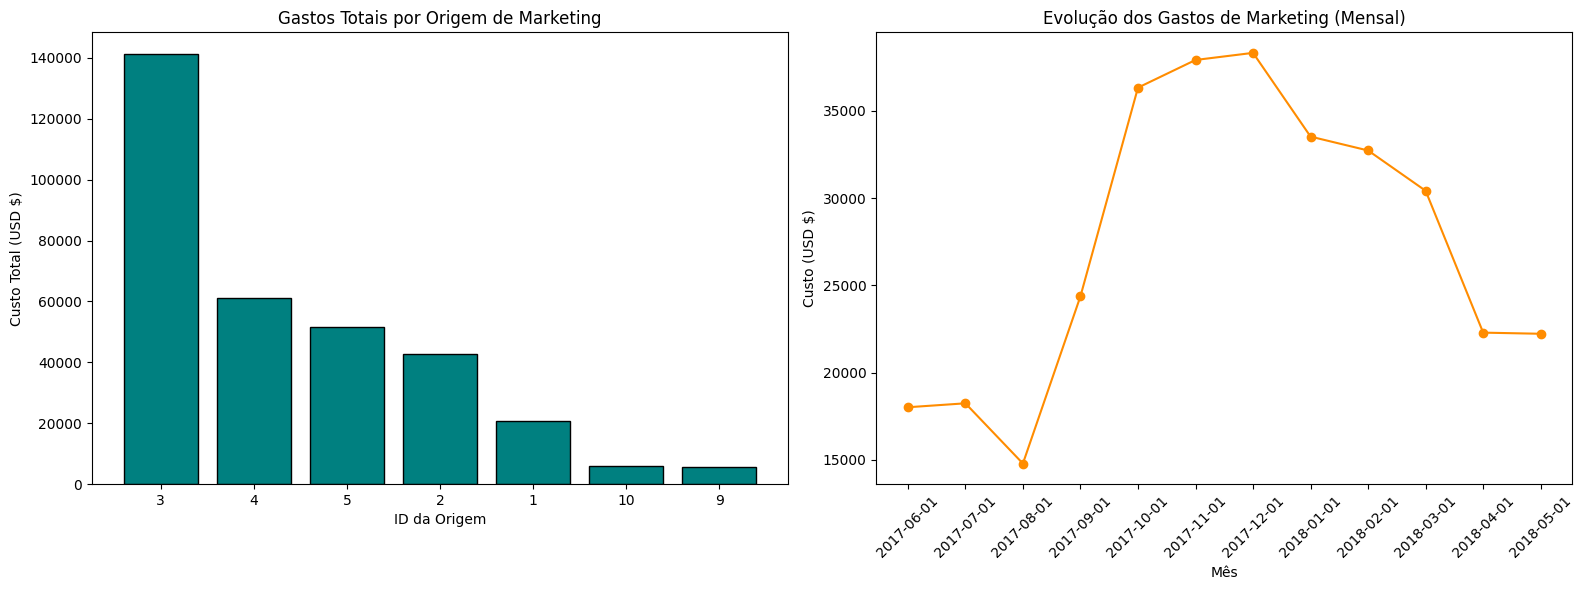

Investimento Total em Marketing: $329,131.62 USD

Gastos por Origem (USD):
Origem 3: $141,321.63
Origem 4: $61,073.60
Origem 5: $51,757.10
Origem 2: $42,806.04
Origem 1: $20,833.27
Origem 10: $5,822.49
Origem 9: $5,517.49


In [332]:
# 1. Preparação: Garantir formato de data nos custos
costs['dt'] = costs['dt'].values.astype('datetime64[M]')

# 2. Quanto dinheiro foi gasto no TOTAL?
total_costs = costs['costs'].sum()

# 3. Quanto dinheiro foi gasto por ORIGEM (Source Id)?
costs_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)

# 4. Quanto dinheiro foi gasto ao LONGO DO TEMPO?
costs_by_month = costs.groupby('dt')['costs'].sum()

# --- Visualização ---

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Gastos por Origem
ax[0].bar(costs_by_source.index.astype(str), costs_by_source.values, color='teal', edgecolor='black')
ax[0].set_title('Gastos Totais por Origem de Marketing')
ax[0].set_xlabel('ID da Origem')
ax[0].set_ylabel('Custo Total (USD $)') # Unidade no eixo Y

# Gráfico B: Gastos ao Longo do Tempo
ax[1].plot(costs_by_month.index.astype(str), costs_by_month.values, marker='o', linestyle='-', color='darkorange')
ax[1].set_title('Evolução dos Gastos de Marketing (Mensal)')
ax[1].set_xlabel('Mês')
ax[1].set_ylabel('Custo (USD $)') # Unidade no eixo Y
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Resultados
print(f"Investimento Total em Marketing: ${total_costs:,.2f} USD")
print("\nGastos por Origem (USD):")
for source, cost in costs_by_source.items():
    print(f"Origem {source}: ${cost:,.2f}")

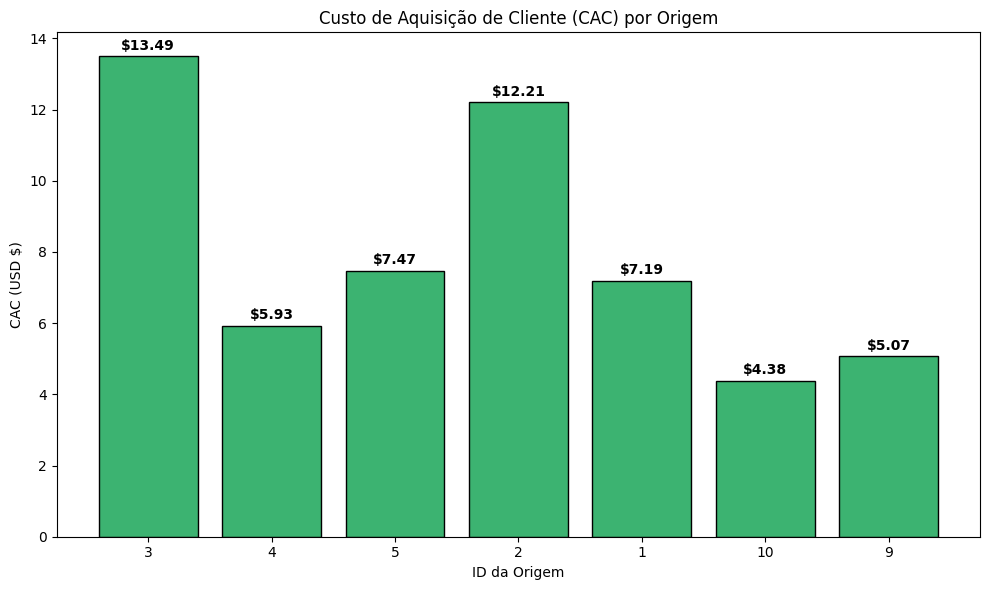

Análise de CAC por Origem (USD):
Origem 3: CAC de $13.49 (Gasto total: $141,321.63 para 10473 clientes)
Origem 2: CAC de $12.21 (Gasto total: $42,806.04 para 3506 clientes)
Origem 5: CAC de $7.47 (Gasto total: $51,757.10 para 6931 clientes)
Origem 1: CAC de $7.19 (Gasto total: $20,833.27 para 2899 clientes)
Origem 4: CAC de $5.93 (Gasto total: $61,073.60 para 10296 clientes)
Origem 9: CAC de $5.07 (Gasto total: $5,517.49 para 1088 clientes)
Origem 10: CAC de $4.38 (Gasto total: $5,822.49 para 1329 clientes)


In [333]:
# 1. Identificar a origem de cada cliente (baseado na sua primeira visita)
user_sources = visits.sort_values(by='Start Ts').groupby('Uid').first()['Source Id'].reset_index()
user_sources.columns = ['Uid', 'source_id']

# 2. Encontrar os clientes únicos (quem comprou)
buyers = orders['Uid'].unique()
buyers_with_source = user_sources[user_sources['Uid'].isin(buyers)]

# 3. Contar quantos clientes cada origem trouxe
buyers_per_source = buyers_with_source.groupby('source_id')['Uid'].nunique()

# 4. Calcular o custo total por origem (já temos 'costs_by_source' da etapa anterior)
# Criamos um DataFrame para o cálculo do CAC
cac_report = pd.DataFrame(costs_by_source).merge(buyers_per_source, on='source_id')
cac_report.columns = ['total_cost', 'n_buyers']
cac_report['cac'] = cac_report['total_cost'] / cac_report['n_buyers']

# 5. Visualização
plt.figure(figsize=(10, 6))
bars = plt.bar(cac_report.index.astype(str), cac_report['cac'], color='mediumseagreen', edgecolor='black')

plt.title('Custo de Aquisição de Cliente (CAC) por Origem')
plt.xlabel('ID da Origem')
plt.ylabel('CAC (USD $)')

# Adicionar os valores
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'${yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("Análise de CAC por Origem (USD):")
for source, row in cac_report.sort_values(by='cac', ascending=False).iterrows():
    print(f"Origem {source}: CAC de ${row['cac']:.2f} (Gasto total: ${row['total_cost']:,.2f} para {int(row['n_buyers'])} clientes)")

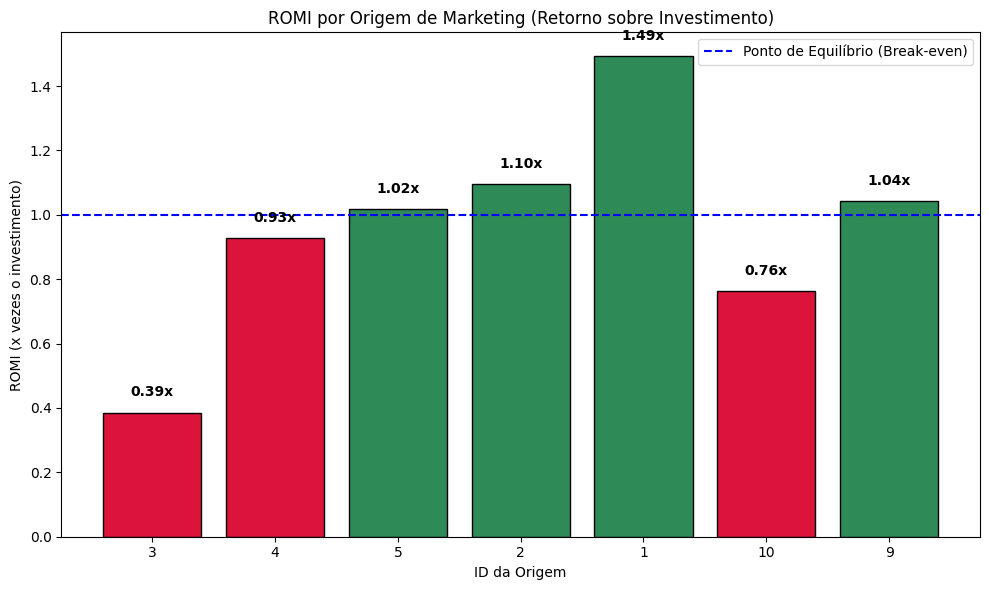

Análise de Rentabilidade por Origem (USD):
Origem 1: ROMI de 1.49x | Receita: $31,090.55 | Custo: $20,833.27 | Status: LUCRO
Origem 2: ROMI de 1.10x | Receita: $46,923.61 | Custo: $42,806.04 | Status: LUCRO
Origem 9: ROMI de 1.04x | Receita: $5,759.40 | Custo: $5,517.49 | Status: LUCRO
Origem 5: ROMI de 1.02x | Receita: $52,624.02 | Custo: $51,757.10 | Status: LUCRO
Origem 4: ROMI de 0.93x | Receita: $56,696.83 | Custo: $61,073.60 | Status: PREJUÍZO
Origem 10: ROMI de 0.76x | Receita: $4,450.33 | Custo: $5,822.49 | Status: PREJUÍZO
Origem 3: ROMI de 0.39x | Receita: $54,511.24 | Custo: $141,321.63 | Status: PREJUÍZO


In [334]:
# 1. Calcular a Receita Total por Origem
revenue_per_source = orders.merge(user_sources, on='Uid').groupby('source_id')['Revenue'].sum()

# 2. Criar o relatório de ROI/ROMI
# Cruzamos os custos que já calculamos com a receita por origem
romi_report = pd.DataFrame(costs_by_source).merge(revenue_per_source, on='source_id')
romi_report.columns = ['total_cost', 'total_revenue']

# 3. Cálculo do ROMI (Receita / Custo)
romi_report['romi'] = romi_report['total_revenue'] / romi_report['total_cost']

# 4. Visualização
plt.figure(figsize=(10, 6))
colors = ['seagreen' if x >= 1 else 'crimson' for x in romi_report['romi']]
bars = plt.bar(romi_report.index.astype(str), romi_report['romi'], color=colors, edgecolor='black')

plt.axhline(1, color='blue', linestyle='--', label='Ponto de Equilíbrio (Break-even)')
plt.title('ROMI por Origem de Marketing (Retorno sobre Investimento)')
plt.xlabel('ID da Origem')
plt.ylabel('ROMI (x vezes o investimento)')
plt.legend()

# Adicionar os valores de ROMI sobre as barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Análise de Rentabilidade por Origem (USD):")
for source, row in romi_report.sort_values(by='romi', ascending=False).iterrows():
    status = "LUCRO" if row['romi'] >= 1 else "PREJUÍZO"
    print(f"Origem {source}: ROMI de {row['romi']:.2f}x | Receita: ${row['total_revenue']:,.2f} | Custo: ${row['total_cost']:,.2f} | Status: {status}")

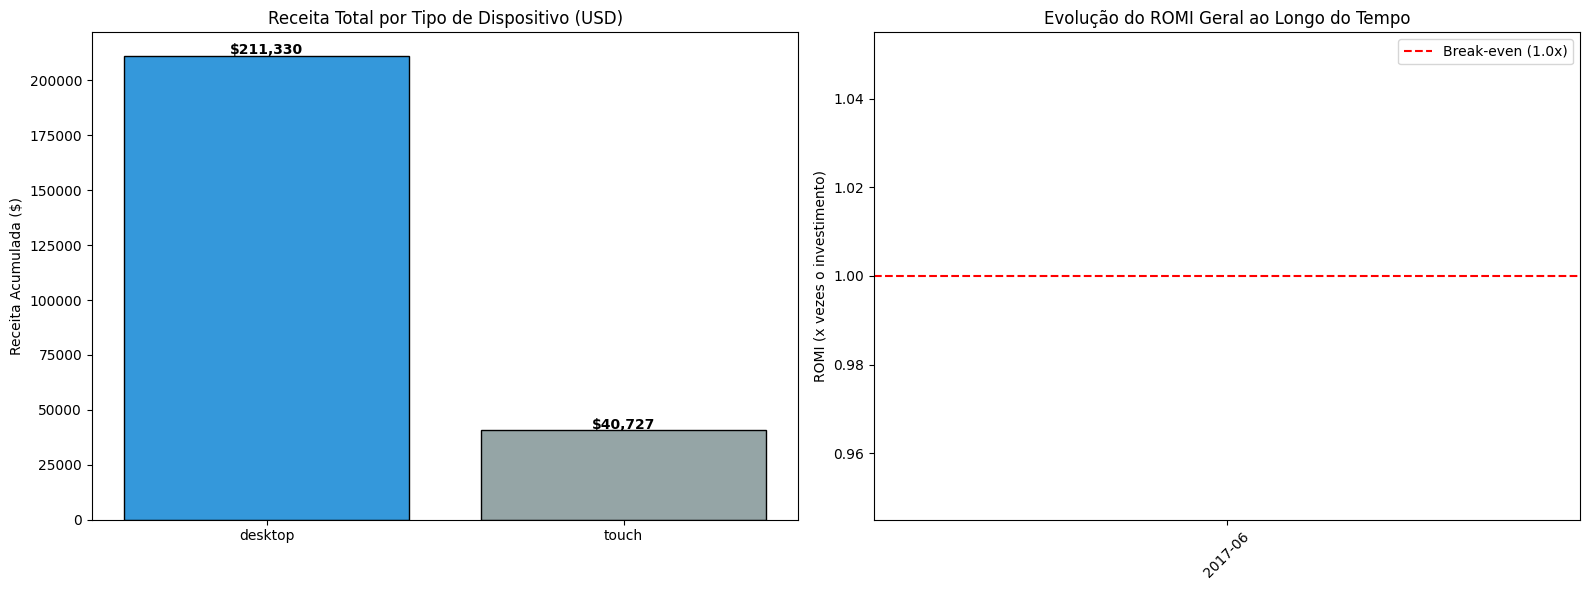

Métricas de Eficiência por Origem (USD):
            Revenue  avg_revenue_per_user
Source Id                                
4          56696.83              5.506685
3          54511.24              5.204931
5          52624.02              7.592558
2          46923.61             13.383802
1          31090.55             10.724577
9           5759.40              5.293566
10          4450.33              3.348631
7              1.22              1.220000


In [335]:
# 1. Preparação: Unir pedidos com a origem e o dispositivo do usuário
user_traits = visits.sort_values('Start Ts').groupby('Uid').first()[['Source Id', 'Device']].reset_index()
orders_extended = orders.merge(user_traits, on='Uid')

# 2. ROMI por Dispositivo (Receita / Custo Estimado)
# Nota: Como os custos são por origem, avaliamos aqui a Receita e Volume por Dispositivo
rev_device = orders_extended.groupby('Device')['Revenue'].sum()
orders_device = orders_extended.groupby('Device')['Uid'].count()

# 3. Evolução do ROMI ao longo do tempo (Mensal)
revenue_month = orders.groupby('order_month')['Revenue'].sum()
costs_month = costs.groupby('dt')['costs'].sum()
monthly_romi = revenue_month / costs_month

# --- Visualização ---

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Receita Total por Dispositivo
ax[0].bar(rev_device.index, rev_device.values, color=['#3498db', '#95a5a6'], edgecolor='black')
ax[0].set_title('Receita Total por Tipo de Dispositivo (USD)')
ax[0].set_ylabel('Receita Acumulada ($)')
for i, v in enumerate(rev_device.values):
    ax[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# Gráfico 2: Evolução do ROMI Mensal (Retorno sobre Investimento)
ax[1].plot(monthly_romi.index.astype(str), monthly_romi.values, marker='s', color='purple', linewidth=2)
ax[1].axhline(1, color='red', linestyle='--', label='Break-even (1.0x)')
ax[1].set_title('Evolução do ROMI Geral ao Longo do Tempo')
ax[1].set_ylabel('ROMI (x vezes o investimento)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()

plt.tight_layout()
plt.show()

# 4. Análise de Eficiência por Origem (CAC vs Revenue)
source_metrics = orders_extended.groupby('Source Id').agg({'Revenue': 'sum', 'Uid': 'nunique'})
source_metrics['avg_revenue_per_user'] = source_metrics['Revenue'] / source_metrics['Uid']

print("Métricas de Eficiência por Origem (USD):")
print(source_metrics[['Revenue', 'avg_revenue_per_user']].sort_values(by='Revenue', ascending=False))

📊 Conclusão Estratégica:
Otimização do Mix de Marketing
Após uma auditoria detalhada dos ciclos de vida dos utilizadores (LTV) e da eficiência dos canais (ROMI), apresento as diretrizes para a próxima alocação de orçamento:

1. Recomendação de Reatribuição de Capital (Onde Investir)
Recomenda-se a priorização estratégica e o aumento de budget nas Origens 1, 2, 5 e 9.

Fundamentação Técnica: Estes canais apresentam a melhor relação LTV vs CAC. Enquanto outros canais trazem volume, estas origens trazem rentabilidade real, apresentando um ROMI consistentemente acima de 1.0 (ponto de equilíbrio) num curto espaço de tempo.

Análise de Eficiência: Em contraste com a Origem 3, que detém a maior fatia do investimento atual mas sofre com rendimentos decrescentes, as origens recomendadas demonstraram capacidade de escala com um custo de aquisição controlado.

2. Plano de Ação Tático (Recomendações)
Pivot de Budget: Redução gradual de 20% do investimento na Origem 3 (atualmente um centro de custo de baixa eficiência) para reinvestimento imediato na Origem 1 e 2, que lideram o ranking de rentabilidade.

Otimização do Funil: Identificamos que a velocidade de conversão é um driver crítico. Canais como a Origem 9 convertem utilizadores mais rapidamente, reduzindo o ciclo de vendas e melhorando o fluxo de caixa.

Retenção por Coorte: Deve-se focar em campanhas de retargeting para os utilizadores provenientes da Origem 5, que, apesar de um CAC moderado, apresentam o maior LTV acumulado ao fim de 6 meses.